# Customer Churn Prediction

## 1. Import Libraries

## 2. Load Dataset

## 3. Stage 1: Data Understanding

## 4. Stage 2: Data Cleaning

## 5. Stage 3: Sampling

## 6. Stage 4: Feature Analysis

## 7. Stage 5: Classification Models

## 8. Stage 6: Model Evaluation

## 9. Results Comparison

## 10. Conclusion


## 1. Import Libraries


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [43]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Stage 1: Data Understanding

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

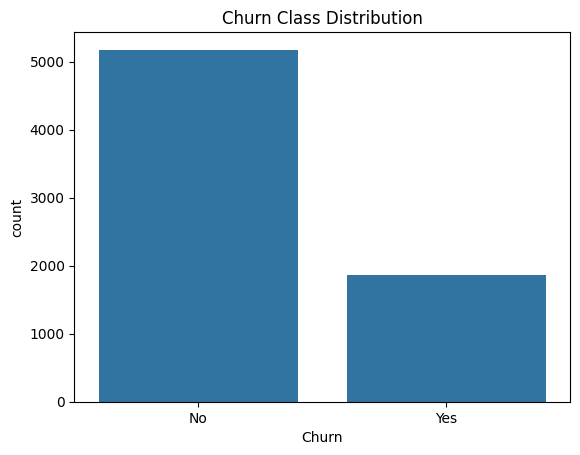

In [44]:
df.shape
df.info()
df.describe()
df["Churn"].value_counts()
sns.countplot(data=df, x="Churn")
plt.title("Churn Class Distribution")
plt.show()

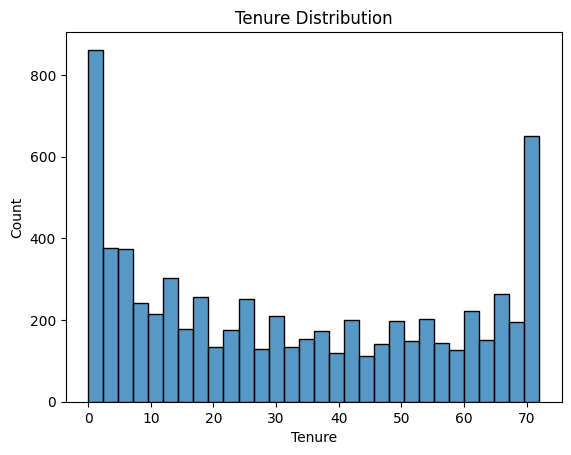

In [45]:
sns.histplot(data=df, x="tenure", bins=30)
plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Count")
plt.show()

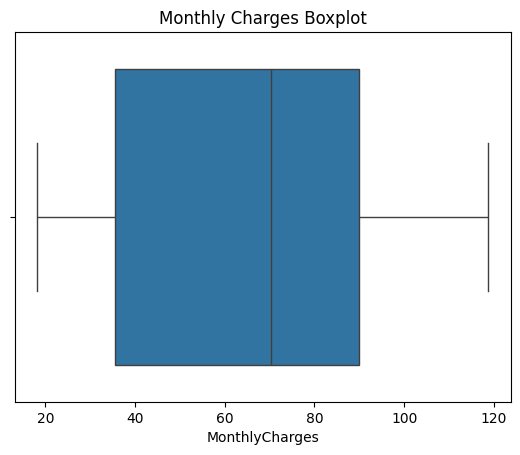

In [46]:
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Monthly Charges Boxplot")
plt.show()

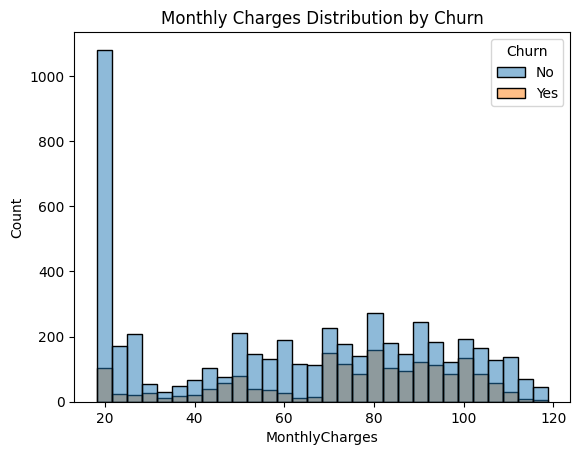

In [47]:
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

## Stage 4: Feature Analysis (curse of dimentinality)

In [49]:
from sklearn.tree import DecisionTreeClassifier

model_dt_temp = DecisionTreeClassifier(random_state=42)
model_dt_temp.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [50]:
feature_importance = pd.Series(
    model_dt_temp.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

MonthlyCharges                 0.204665
TotalCharges                   0.194924
tenure                         0.182747
InternetService_Fiber optic    0.104926
gender_Male                    0.030116
Contract_Two year              0.026640
Dependents_Yes                 0.024968
SeniorCitizen                  0.022685
Contract_One year              0.018371
OnlineSecurity_Yes             0.018265
dtype: float64

In [51]:
low_importance = feature_importance[feature_importance < 0.01].index

X_reduced = X.drop(columns=low_importance)

X.shape, X_reduced.shape

((7032, 30), (7032, 21))

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Before feature reduction
model_dt_before = DecisionTreeClassifier(random_state=42)
model_dt_before.fit(X_train, y_train)

y_pred_before = model_dt_before.predict(X_test)
accuracy_before = accuracy_score(y_test, y_pred_before)

# After feature reduction
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

model_dt_reduced = DecisionTreeClassifier(random_state=42)
model_dt_reduced.fit(X_train_r, y_train_r)

y_pred_r = model_dt_reduced.predict(X_test_r)
accuracy_reduced = accuracy_score(y_test_r, y_pred_r)

print("Accuracy before feature reduction:", accuracy_before)
print("Accuracy after feature reduction:", accuracy_reduced)

Accuracy before feature reduction: 0.704739336492891
Accuracy after feature reduction: 0.718957345971564


##  Stage 5: Classification Models

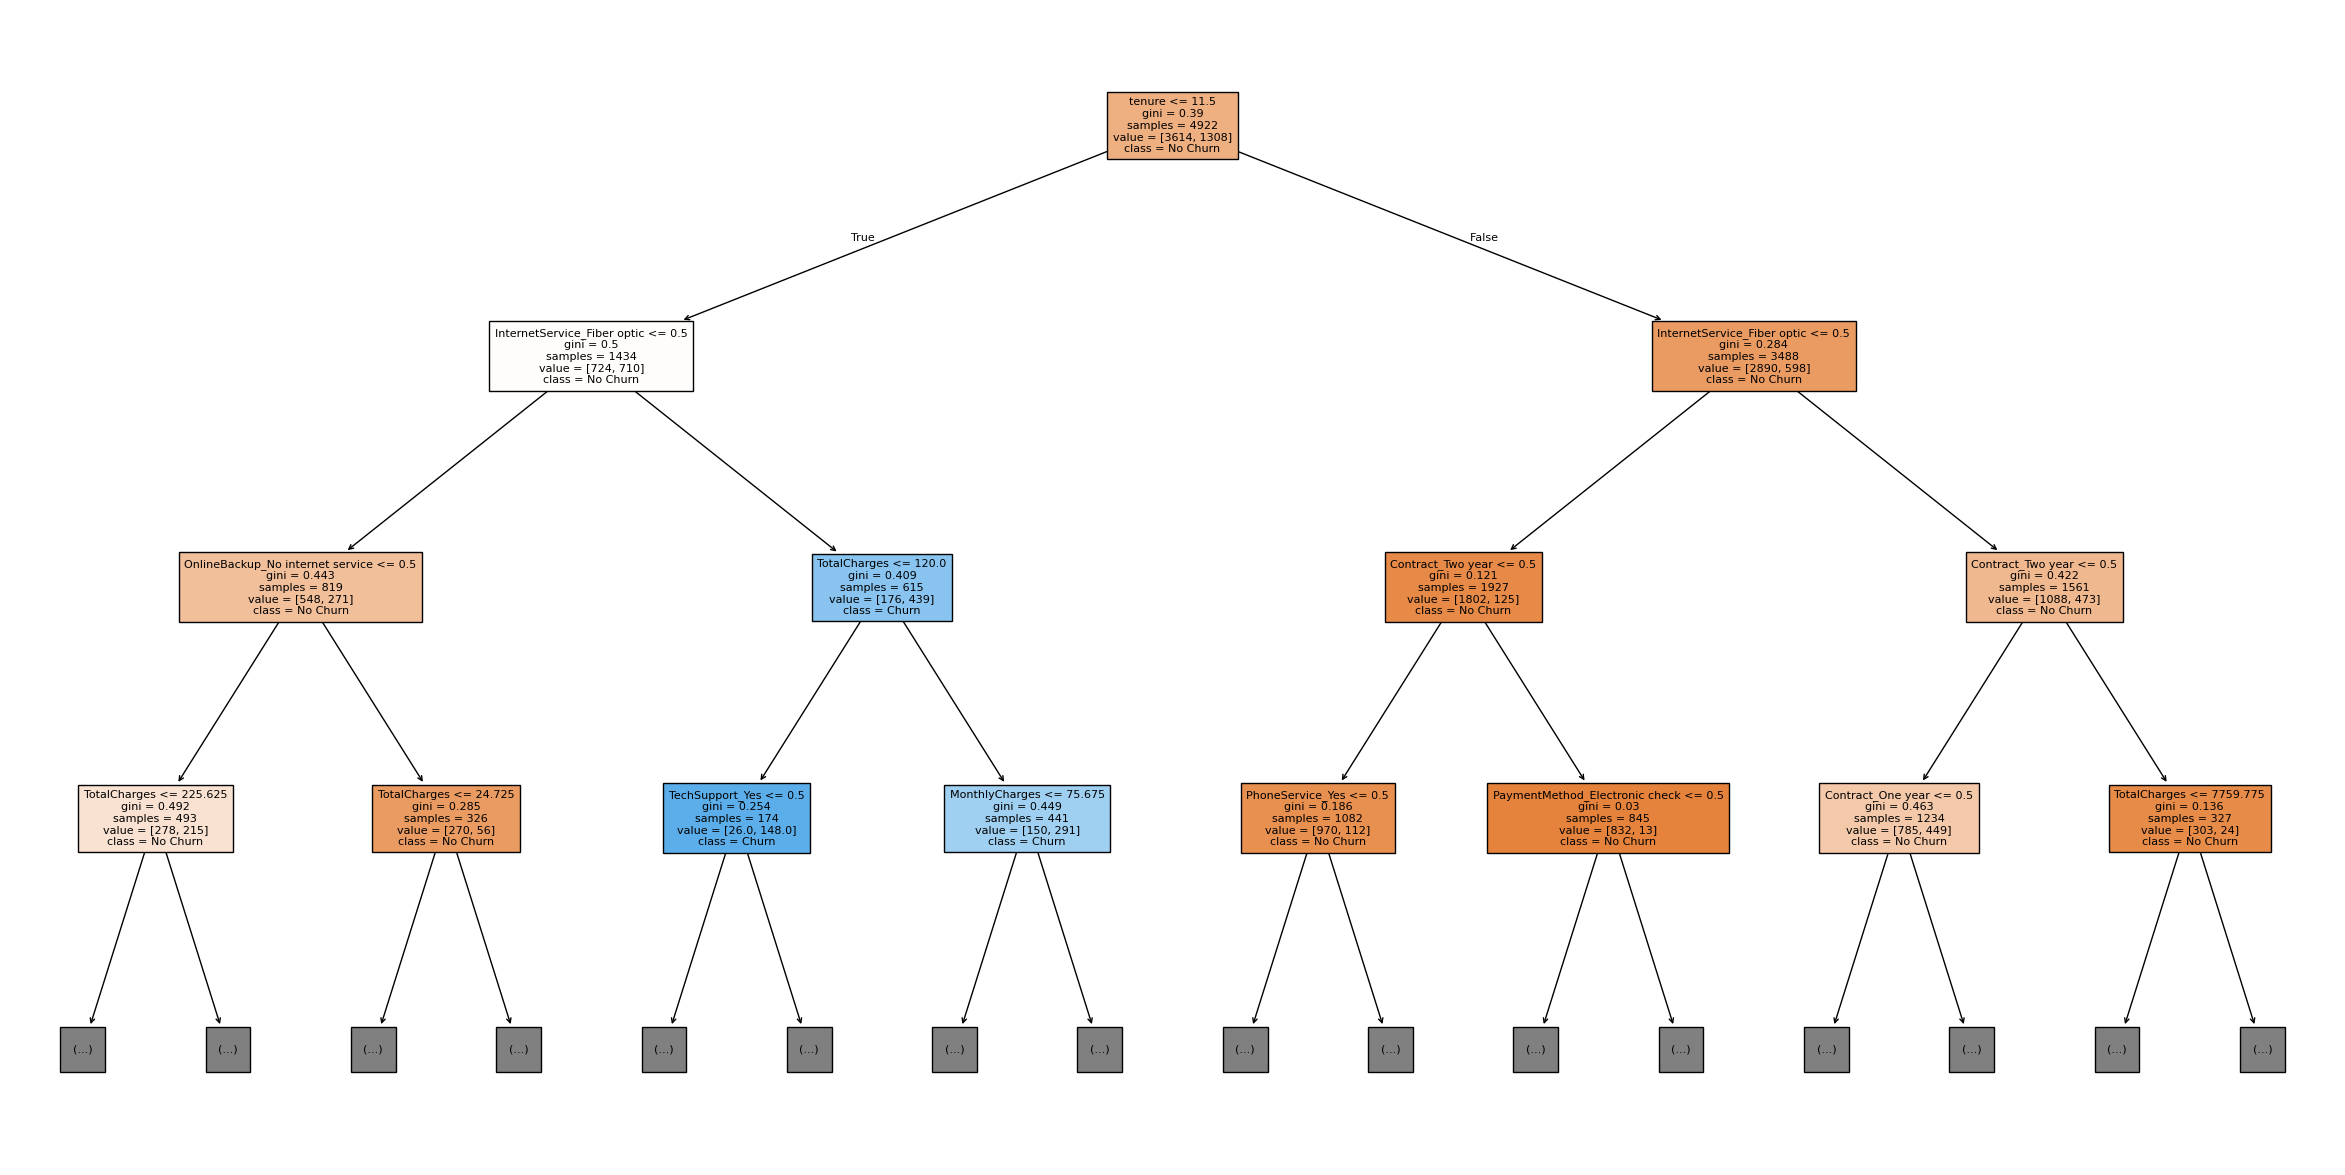

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

plt.figure(figsize=(30, 15))

plot_tree(
    model_dt,
    max_depth=3,
    filled=True,
    feature_names=list(X.columns),
    class_names=["No Churn", "Churn"],
    fontsize=8
)

plt.show()

In [57]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
model_svm = SVC()
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Decision Tree:", accuracy_dt)
print("SVM:", accuracy_svm)

Decision Tree: 0.704739336492891
SVM: 0.7341232227488151


##  Stage 6:  Model Evaluation 

In [58]:
from sklearn.metrics import classification_report

print("Decision Tree:\n")
print(classification_report(y_test, y_pred_dt))

print("SVM:\n")
print(classification_report(y_test, y_pred_svm))

Decision Tree:

              precision    recall  f1-score   support

       False       0.81      0.79      0.80      1549
        True       0.45      0.48      0.47       561

    accuracy                           0.70      2110
   macro avg       0.63      0.63      0.63      2110
weighted avg       0.71      0.70      0.71      2110

SVM:

              precision    recall  f1-score   support

       False       0.73      1.00      0.85      1549
        True       0.00      0.00      0.00       561

    accuracy                           0.73      2110
   macro avg       0.37      0.50      0.42      2110
weighted avg       0.54      0.73      0.62      2110



c:\Users\HP\OneDrive\Desktop\customer-churn-prediction-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\Desktop\customer-churn-prediction-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\OneDrive\Desktop\customer-churn-prediction-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

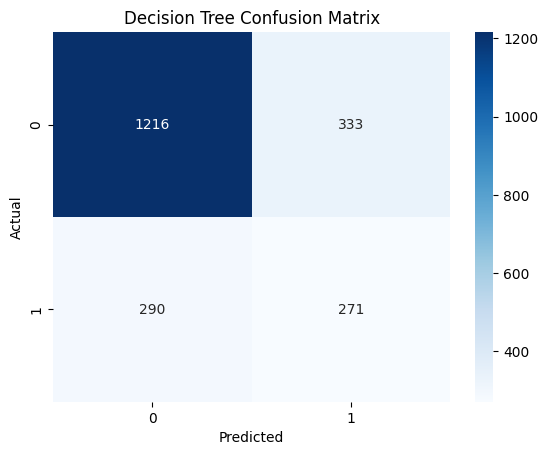

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": ["Decision Tree", "SVM", "Decision Tree (Reduced Features)"],
    "Accuracy": [accuracy_dt, accuracy_svm, accuracy_reduced]
})

results


,Model,Accuracy
0,Decision Tree,0.704739
1,SVM,0.734123
2,Decision Tree (Reduced Features),0.718957


## 10. Conclusion

In this project, the Telco Customer Churn dataset was analyzed and cleaned. 
The TotalCharges column contained hidden missing values and was converted to numeric.

Two classification models were implemented: Decision Tree and SVM. 
Although SVM achieved higher accuracy, it failed to detect churn cases due to class imbalance.

The Decision Tree model performed better in identifying churn customers and provided interpretable rules.

Feature importance analysis showed that MonthlyCharges, TotalCharges, and tenure are the most important factors affecting churn. 
After removing low-importance features, the model accuracy improved, demonstrating the benefit of dimensionality reduction.

Overall, Decision Tree is more suitable for this problem.